In [1]:
# load data
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("ForeignGifts_edu.csv")
# avoiding scientific notation  
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df['Foreign Gift Received Date'] = pd.to_datetime(
    df['Foreign Gift Received Date'],
    unit = 'D',
    origin = '1899-12-30'
)
# was baffled by why the dates were just random integers - they're serial dates representing days since 1899-12-30

In [13]:
oldest = df["Foreign Gift Received Date"].min()
newest = df["Foreign Gift Received Date"].max()

print(f"Oldest gift date: {oldest}")
print(f"Most recent gift date: {newest}")

Oldest gift date: 2014-01-01 00:00:00
Most recent gift date: 2020-06-30 00:00:00


In [3]:
# isolating uva data
uva = df[df["Institution Name"] == "University of Virginia"]
# checking that i captured it
uva["Institution Name"].unique()

<StringArray>
['University of Virginia']
Length: 1, dtype: str

Describing UVA's foreign giving on its own.

In [4]:
print(f"Number of UVA gift records: {len(uva)}")
uva.head()

Number of UVA gift records: 98


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,2014-07-02,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,2014-08-19,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,2014-08-22,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,2014-09-05,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,2014-09-22,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [5]:
# total money received
total_received = uva["Foreign Gift Amount"].sum()
print(f"Total money received by UVA: ${total_received:,.2f}")

Total money received by UVA: $22,189,238.00


In [6]:
# gift count
gift_count = len(uva)
print(f"Number of UVA gifts: {gift_count}")

Number of UVA gifts: 98


In [7]:
# mean v median gift size
mean_gift_size = uva["Foreign Gift Amount"].mean()
median_gift_size = uva["Foreign Gift Amount"].median()
print(f"Mean gift size: ${mean_gift_size:,.2f}")
print(f"Median gift size: ${median_gift_size:,.2f}")
print(f"Difference between mean and median: ${mean_gift_size - median_gift_size:,.2f}")

Mean gift size: $226,420.80
Median gift size: $80,535.50
Difference between mean and median: $145,885.30


In [8]:
# full descriptive statistics
uva["Foreign Gift Amount"].describe()

count        98.0000
mean     226420.7959
std      343305.1476
min          31.0000
25%        9450.0000
50%       80535.5000
75%      276888.2500
max     1708021.0000
Name: Foreign Gift Amount, dtype: float64

In [9]:
# top countries giving to UVA
top_countries = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .agg(total="sum", count="count", mean="mean")
    .sort_values("total", ascending=False)
)
print(top_countries.head(10))


                     total  count         mean
Country of Giftor                             
BANGLADESH         4228589     10  422858.9000
SWEDEN             4007552     10  400755.2000
TANZANIA           2776447      3  925482.3333
SWITZERLAND        2000000      2 1000000.0000
ENGLAND            1950666     31   62924.7097
GUERNSEY           1500000      3  500000.0000
FINLAND            1008384      7  144054.8571
BERMUDA             900000      1  900000.0000
KOREA               862787      6  143797.8333
SINGAPORE           805000      2  402500.0000


                              total  count
Foreign Gift Received Date                
2014                        1050235     15
2015                        3349261     10
2016                        6780205     31
2017                        4422550     25
2018                        2607739      9
2019                        3979248      8


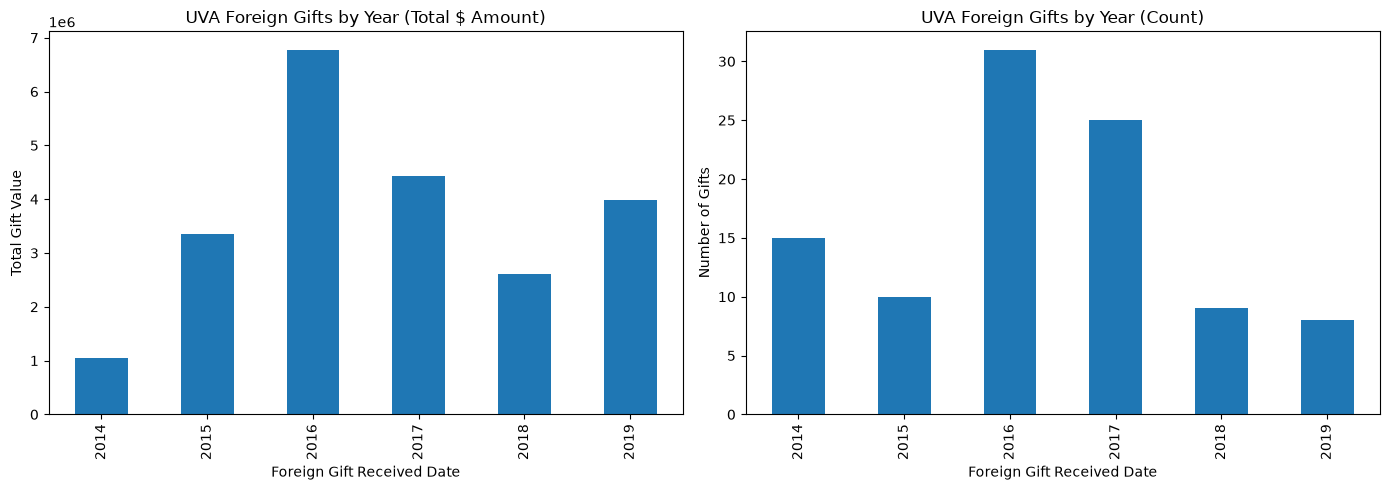

In [10]:
uva_by_year = uva.groupby(uva["Foreign Gift Received Date"].dt.year)["Foreign Gift Amount"].agg(total="sum", count="count")
print(uva_by_year)

# visualizing trend over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
uva_by_year["total"].plot(kind="bar", ax=axes[0], title="UVA Foreign Gifts by Year (Total $ Amount)")
axes[0].set_ylabel("Total Gift Value")
uva_by_year["count"].plot(kind="bar", ax=axes[1], title="UVA Foreign Gifts by Year (Count)")
axes[1].set_ylabel("Number of Gifts")
plt.tight_layout()
plt.show()


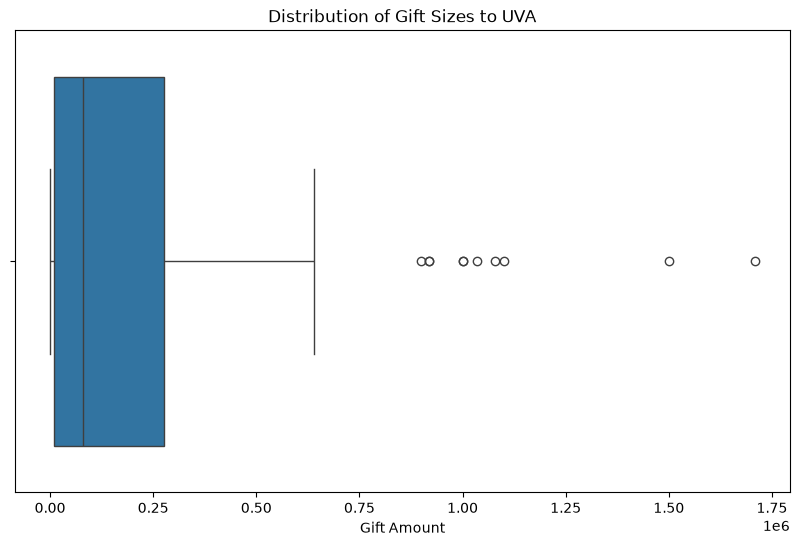

In [11]:
# showing distribution shape
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=uva["Foreign Gift Amount"])
plt.title("Distribution of Gift Sizes to UVA")
plt.xlabel("Gift Amount")
plt.show()

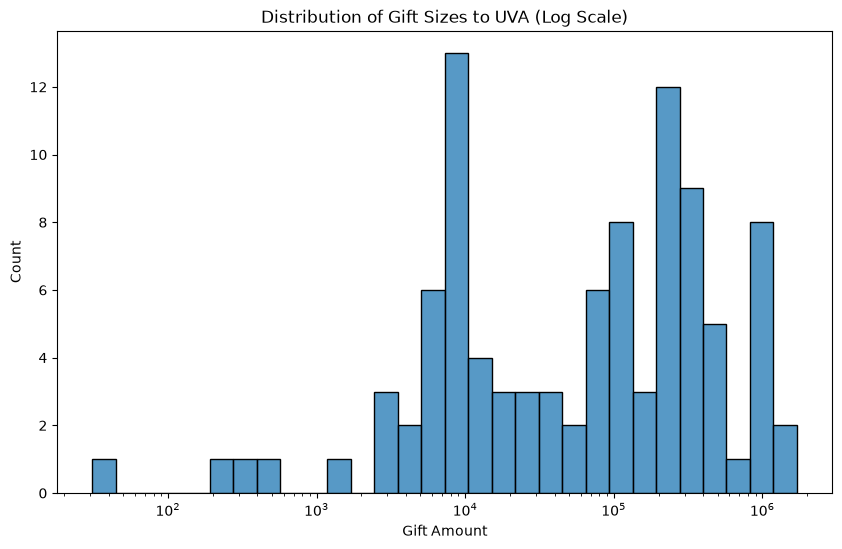

In [12]:
# distribution on log scale because of the severe skew 
plt.figure(figsize=(10, 6))
sns.histplot(uva["Foreign Gift Amount"], bins=30, log_scale=True)
plt.title("Distribution of Gift Sizes to UVA (Log Scale)")
plt.xlabel("Gift Amount")
plt.show()

**Peer Comparison**
I am using a report from the Institution of Education Sciences IPEDS Data Feedback Report from 2023 to determine what schools I compare UVA to. It can be found here: https://nces.ed.gov/ipeds/dfr/2023/ReportHTML.aspx?unitId=234076

In [14]:
peer_list = [
    "Cornell University",
    "Duke University",
    "Emory University",
    "Georgia Institute of Technology-Main Campus",
    "Johns Hopkins University",
    "New York University",
    "The University of Texas at Austin",
    "University of California-Berkeley",
    "University of California-Los Angeles",
    "University of Florida"
]

In [16]:
peer_df = df[df["Institution Name"].isin(peer_list)]
peer_df.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
11247,11248,153500,University of Florida,Gainesville,FL,2018-02-22,343790,Contract,SWITZERLAND,DSM Nutritional Products AG
11248,11249,153500,University of Florida,Gainesville,FL,2018-03-08,1693595,Contract,JAPAN,GLOBAL HEALTH INNOVATIVE TECHNOLOGY
11249,11250,153500,University of Florida,Gainesville,FL,2018-03-13,347586,Contract,THE NETHERLANDS,RIJK ZWAAN ZAADTEELT EN ZAADHANDEL
11250,11251,153500,University of Florida,Gainesville,FL,2018-08-01,274827,Contract,SOUTH KOREA,Korea Sports Promotion Foundation
11251,11252,153500,University of Florida,Gainesville,FL,2018-09-26,762500,Contract,IRELAND,United Neuroscience Limited
11252,11253,153500,University of Florida,Gainesville,FL,2019-01-01,2277135,Contract,SAUDI ARABIA,Royal Embassy of Saudi Arabia
11253,11254,153500,University of Florida,Gainesville,FL,2019-01-02,457836,Contract,SWITZERLAND,F Hoffmann La Roche LTD
11254,11255,153500,University of Florida,Gainesville,FL,2019-01-24,425392,Contract,AUSTRALIA,CSL BEHRING
11255,11256,153500,University of Florida,Gainesville,FL,2019-01-24,680781,Contract,AUSTRALIA,CSL Behring
11256,11257,153500,University of Florida,Gainesville,FL,2019-01-25,314823,Contract,SWITZERLAND,CRISPR THERAPEUTICS AG


In [17]:
# gap analysis: countries giving lots to peer institutions but little to UVA
peer_by_country = peer_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
uva_by_country = uva.groupby("Country of Giftor")["Foreign Gift Amount"].sum()

comparison = pd.DataFrame({
    "peer_total": peer_by_country,
    "uva_total": uva_by_country
}).fillna(0)
comparison["gap"] = comparison["peer_total"] - comparison["uva_total"]
comparison_sorted = comparison.sort_values("gap", ascending=False)
comparison_sorted.head(10)

,peer_total,uva_total,gap
Country of Giftor,,,
QATAR,1021019242,0.0000,1021019242.0000
FRANCE,154953191,250383.0000,154702808.0000
SWITZERLAND,129340980,2000000.0000,127340980.0000
ENGLAND,124459803,1950666.0000,122509137.0000
CHINA,94174175,0.0000,94174175.0000
CANADA,90181154,0.0000,90181154.0000
INDIA,79370364,0.0000,79370364.0000
SWEDEN,76811758,4007552.0000,72804206.0000
MONACO,58866983,0.0000,58866983.0000


In [ ]:

df["Year"] = df["Foreign Gift Received Date"].dt.year
country_year_trend = df.groupby(["Country of Giftor", "Foreign Gift Year"].dt.year)

country_year_trend.loc[["Qatar", "France", "Switzerland"]]

KeyError: 'Year'